### Sección: Análisis Exploratorio de Datos (EDA) en Desarrollo

Esta sección está dedicada a la **exploración iterativa y minería de datos sobre el dataset del Censo de la Provincia de Salta**. El objetivo principal es interrogar la base de datos desde múltiples dimensiones para visibilizar y localizar geográficamente las necesidades estructurales de la población.

Este espacio se encuentra en **constante desarrollo**. A medida que se descubran nuevos patrones, anomalías o variables críticas, se irán incorporando de forma secuencial nuevas consultas y visualizaciones con el fin de transformar datos crudos en un **diagnóstico territorial accionable** para la planificación de mejoras y obras públicas.

In [1]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
load_dotenv()

DB_CONFIG = {
    "dbname": os.getenv("POSTGRES_DB"),
    "user": os.getenv("POSTGRES_USER"),
    "password": os.getenv("POSTGRES_PASSWORD"),
    "host": os.getenv("POSTGRES_HOST"),
    "port": os.getenv("POSTGRES_PORT"),
}

DATABASE_URL = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
)

engine = create_engine(DATABASE_URL, pool_pre_ping=True)

In [3]:
query_nbi = """
    SELECT 
        dg.departamento,
        dc.categoria AS condicion_social,
        SUM(fh.cantidad) AS total_hogares
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    JOIN dim_geografia dg ON fh.codigo = dg.codigo
    WHERE dv.cod_variable = 'HOGAR_NBI_TOT'
    GROUP BY dg.departamento, dc.categoria;
"""

df_raw = pd.read_sql(query_nbi, engine)

df_raw['condicion_social'] = df_raw['condicion_social'].str.lower().map({'sí': 'Insatisfecho', 'no': 'Satisfecho'})

df_raw['total_hogares'] = df_raw['total_hogares'].astype(int)
df_raw['porcentaje'] = (df_raw['total_hogares'] / df_raw.groupby('departamento')['total_hogares'].transform('sum')) * 100
df_raw['porcentaje'] = df_raw['porcentaje'].round(2)

df_raw['p_insatisfecho'] = df_raw['porcentaje'].where(df_raw['condicion_social'] == 'Insatisfecho')

df_raw['orden_depto'] = df_raw.groupby('departamento')['p_insatisfecho'].transform('max')

df_ordenado = df_raw.sort_values(
    by=['orden_depto', 'departamento', 'condicion_social'], 
    ascending=[False, True, False]
)

df_ordenado = df_ordenado.drop(columns=['p_insatisfecho', 'orden_depto']).reset_index(drop=True)

print("Estructura de estratos ordenada por porcentaje de insatisfacción:")
display(df_ordenado)

Estructura de estratos ordenada por porcentaje de insatisfacción:


,departamento,condicion_social,total_hogares,porcentaje
0,Rivadavia,Satisfecho,6654,60.08
1,Rivadavia,Insatisfecho,4421,39.92
2,General Jose de San Martin,Satisfecho,39552,78.40
3,General Jose de San Martin,Insatisfecho,10897,21.60
4,Oran,Satisfecho,35458,80.14
5,Oran,Insatisfecho,8787,19.86
6,Anta,Satisfecho,15524,80.20
7,Anta,Insatisfecho,3833,19.80
8,Guachipas,Satisfecho,902,82.15
9,Guachipas,Insatisfecho,196,17.85


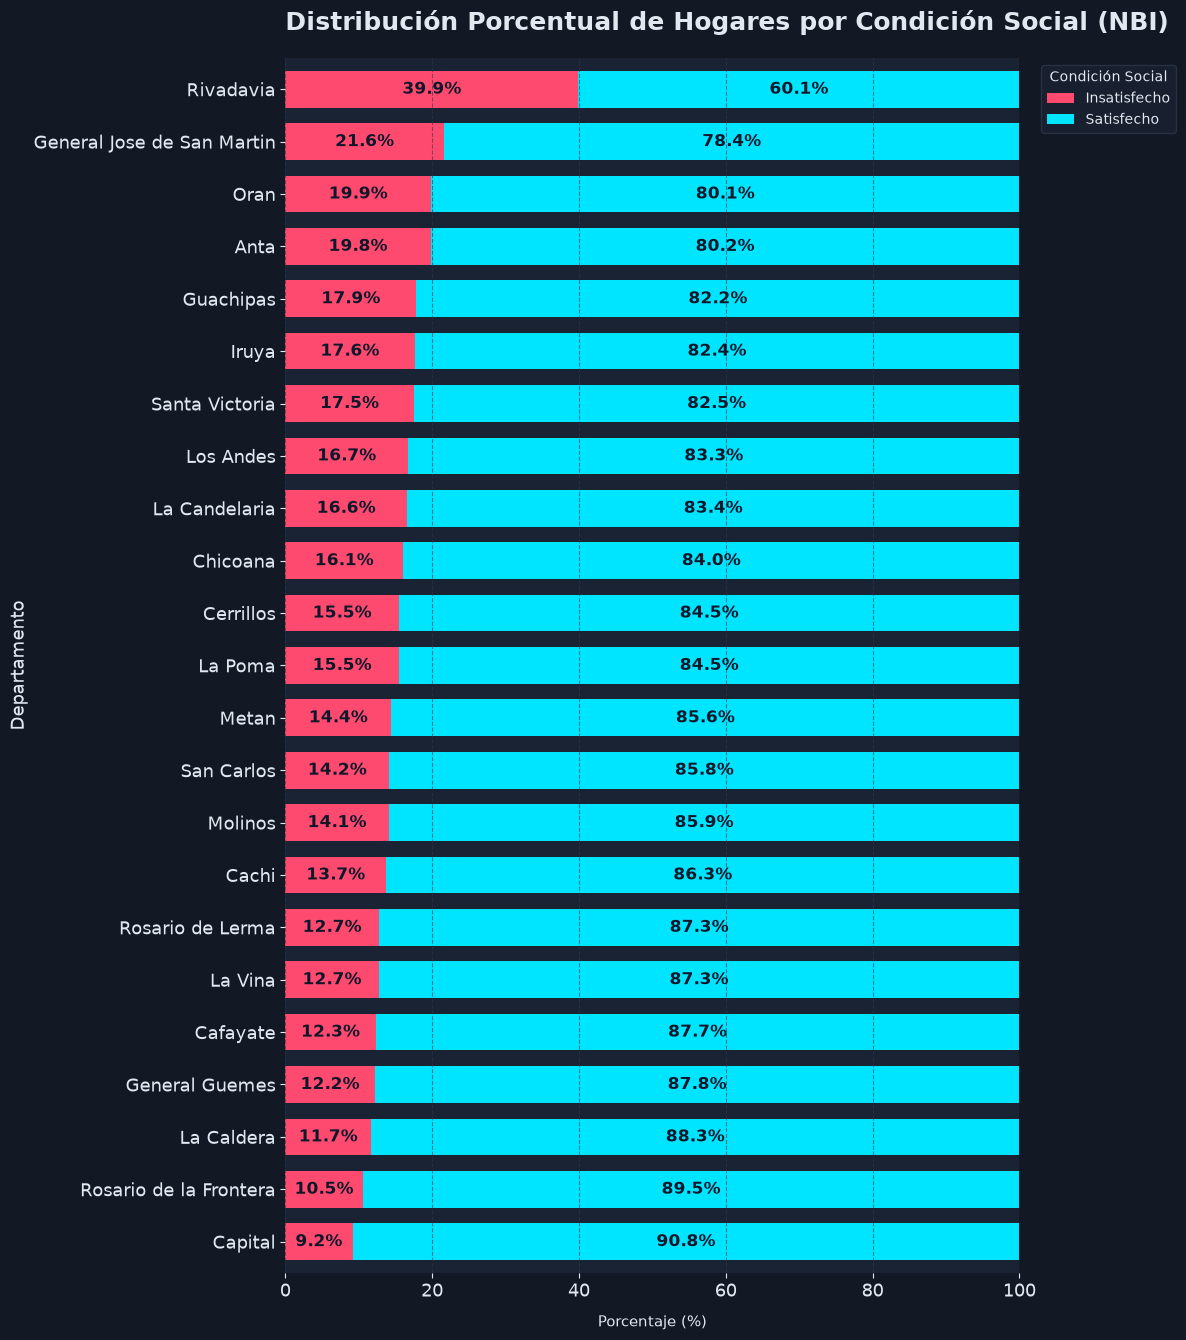

In [4]:
FONDO_OSCURO = '#121824'
FONDO_GRAFICO = '#1a2333'
COLOR_TEXTO = '#E2E8F0'
COLOR_GRILLA = '#2D3748'

df_plot = df_ordenado.pivot(index='departamento', columns='condicion_social', values='porcentaje')
deptos_ordenados = df_ordenado[df_ordenado['condicion_social'] == 'Insatisfecho'].sort_values(by='porcentaje', ascending=True)['departamento']
df_plot = df_plot.loc[deptos_ordenados]

fig, ax = plt.subplots(figsize=(12, len(df_plot) * 0.5 + 2), facecolor=FONDO_OSCURO)
ax.set_facecolor(FONDO_GRAFICO)

colores_premium = ['#FF4A70', '#00E5FF'] 
df_plot[['Insatisfecho', 'Satisfecho']].plot(kind='barh', stacked=True, color=colores_premium, ax=ax, width=0.7)

for p in ax.patches:
    width = p.get_width()
    if width > 5:  
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2, 
                f'{width:.1f}%', 
                ha='center', va='center', 
                color='#0F172A', fontweight='bold', fontsize=12.5)

ax.set_title('Distribución Porcentual de Hogares por Condición Social (NBI)', 
             fontsize=18, fontweight='bold', pad=20, loc='left', color=COLOR_TEXTO)
ax.set_xlabel('Porcentaje (%)', fontsize=11, labelpad=10, color=COLOR_TEXTO)
ax.set_ylabel('Departamento', fontsize=13, color=COLOR_TEXTO)
ax.set_xlim(0, 100)

ax.tick_params(axis='x', colors=COLOR_TEXTO, labelsize=13)
ax.tick_params(axis='y', colors=COLOR_TEXTO, labelsize=13)
ax.grid(True, axis='x', color=COLOR_GRILLA, linestyle='--', alpha=0.6)
sns.despine(left=True, bottom=True)

leyenda = ax.legend(title='Condición Social', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
leyenda.get_frame().set_facecolor(FONDO_GRAFICO)
leyenda.get_frame().set_edgecolor(COLOR_GRILLA)
leyenda.get_title().set_color(COLOR_TEXTO)
for text in leyenda.get_texts():
    text.set_color(COLOR_TEXTO)

plt.tight_layout()
plt.show()

In [5]:
query_geo = """
SELECT 
    codigo AS id_radio, 
    departamento, 
    geometry 
FROM public.geo_radios_2022;
"""
geo_radios = gpd.read_postgis(query_geo, engine, geom_col="geometry", crs="EPSG:4326")

query_nbi = """
SELECT 
    fh.codigo AS id_radio,
    SUM(CASE WHEN dc.categoria = 'sí' THEN fh.cantidad ELSE 0 END) AS hogares_nbi,
    SUM(fh.cantidad) AS total_hogares
FROM fact_hogar fh
JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
JOIN dim_variables dv ON dc.id_variable = dv.id_variable
WHERE dv.cod_variable = 'HOGAR_NBI_TOT'
GROUP BY fh.codigo;
"""
df_hogar = pd.read_sql(query_nbi, engine)

geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()
df_hogar["id_radio"] = df_hogar["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_hogar, on="id_radio", how="left")

geo_df["porcentaje_nbi"] = (geo_df["hogares_nbi"] / geo_df["total_hogares"] * 100).fillna(0)
geo_df["porcentaje_nbi"] = geo_df["porcentaje_nbi"].round(2)

centro_y = geo_df.geometry.centroid.y.mean()
centro_x = geo_df.geometry.centroid.x.mean()

m = folium.Map(
    location=[centro_y, centro_x],
    zoom_start=8,
    tiles="OpenStreetMap"
)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)

geo_df_simplificado = geo_df_simplificado.set_index("id_radio", drop=False)

folium.Choropleth(
    geo_data=geo_df_simplificado.__geo_interface__,
    data=geo_df_simplificado,
    columns=["id_radio", "porcentaje_nbi"],
    key_on="feature.id",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.20,
    line_color="#444444",
    legend_name="Hogares con Necesidades Básicas Insatisfechas - NBI (%)"
).add_to(m)

folium.GeoJson(
    geo_df_simplificado.__geo_interface__,
    style_function=lambda feature: {
        "fillOpacity": 0,
        "color": "transparent",
        "weight": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "departamento",
            "id_radio",
            "total_hogares",
            "hogares_nbi",
            "porcentaje_nbi"
        ],
        aliases=[
            "Departamento:",
            "Código Radio:",
            "Total hogares:",
            "Hogares NBI:",
            "NBI (%):"
        ],
        localize=True,
        sticky=False
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save("mapas_generados/mapa_necesidades_salta.html")
print('mapa guardado en la carpeta mapas generados')

mapa guardado en la carpeta mapas generados


In [6]:
query_nbi = """
SELECT 
    fh.codigo AS id_radio,
    SUM(CASE WHEN LOWER(TRIM(dc.categoria)) = 'sí' THEN fh.cantidad ELSE 0 END) AS hogares_nbi,
    SUM(fh.cantidad) AS total_hogares
FROM fact_hogar fh
JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
JOIN dim_variables dv ON dc.id_variable = dv.id_variable
WHERE dv.cod_variable = 'HOGAR_NBI_TOT'
GROUP BY fh.codigo;
"""
df_hogar = pd.read_sql(query_nbi, engine)

geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()
df_hogar["id_radio"] = df_hogar["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_hogar, on="id_radio", how="left")

geo_df["hogares_nbi"] = geo_df["hogares_nbi"].fillna(0).astype(int)
geo_df["total_hogares"] = geo_df["total_hogares"].fillna(0).astype(int)

geo_df["porcentaje_nbi"] = (geo_df["hogares_nbi"] / geo_df["total_hogares"] * 100).fillna(0)
geo_df["porcentaje_nbi"] = geo_df["porcentaje_nbi"].round(2)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)

df_top_30 = geo_df_simplificado.sort_values(by="porcentaje_nbi", ascending=False).head(30)

print("Top 30 de radios censales con mayor nivel de Necesidades Básicas Insatisfechas (NBI):")
display(df_top_30[["departamento", "id_radio", "total_hogares", "hogares_nbi", "porcentaje_nbi"]].reset_index(drop=True))


Top 30 de radios censales con mayor nivel de Necesidades Básicas Insatisfechas (NBI):


,departamento,id_radio,total_hogares,hogares_nbi,porcentaje_nbi
0,General Jose de San Martin,660560706,184,142,77.17
1,Rivadavia,661330210,351,221,62.96
2,Rivadavia,661330108,251,158,62.95
3,Rivadavia,661330510,158,99,62.66
4,Rivadavia,661330415,231,140,60.61
5,Rivadavia,661330109,166,100,60.24
6,General Jose de San Martin,660560308,205,119,58.05
7,General Jose de San Martin,660561202,225,127,56.44
8,General Jose de San Martin,660561203,271,152,56.09
9,General Jose de San Martin,660560311,207,116,56.04


In [7]:
from sqlalchemy import text


query_escrituras = """
    SELECT 
        COALESCE(dg.departamento, 'Interior Disperso / Parajes') AS departamento,
        fh.codigo AS id_radio,
        SUM(fh.cantidad) - SUM(CASE WHEN dc.cod_categoria = 1 THEN fh.cantidad ELSE 0 END) AS hogares_sin_escritura,
        SUM(fh.cantidad) AS total_hogares
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    LEFT JOIN dim_geografia dg ON TRIM(fh.codigo) = TRIM(dg.codigo)
    WHERE dv.cod_variable = 'HOGAR_H23'
    GROUP BY dg.departamento, fh.codigo;
"""

df_escritura_ind = pd.read_sql(text(query_escrituras), engine)

df_escritura_ind["id_radio"] = df_escritura_ind["id_radio"].astype(str).str.strip()
df_escritura_ind["hogares_sin_escritura"] = df_escritura_ind["hogares_sin_escritura"].astype(int)
df_escritura_ind["total_hogares"] = df_escritura_ind["total_hogares"].astype(int)

df_escritura_ind["porcentaje_informalidad"] = np.where(
    df_escritura_ind["total_hogares"] > 0,
    (df_escritura_ind["hogares_sin_escritura"] / df_escritura_ind["total_hogares"] * 100),
    0
).round(2)

df_informalidad_positiva = df_escritura_ind[df_escritura_ind["porcentaje_informalidad"] > 0].copy()

df_ranking_refinado = df_informalidad_positiva.sort_values(
    by=["porcentaje_informalidad", "total_hogares"], 
    ascending=[False, False]
).reset_index(drop=True)

total_radios_con_informalidad = len(df_ranking_refinado)

print(f"Cantidad de registros de radios censales con informalidad dominial detectada (> 0%): {total_radios_con_informalidad:,}")

print("\nTop 30 de radios censales refinados (Informalidad > 0%):")
display(df_ranking_refinado[["departamento", "id_radio", "total_hogares", "hogares_sin_escritura", "porcentaje_informalidad"]].head(30))

Cantidad de registros de radios censales con informalidad dominial detectada (> 0%): 1,801

Top 30 de radios censales refinados (Informalidad > 0%):


,departamento,id_radio,total_hogares,hogares_sin_escritura,porcentaje_informalidad
0,Capital,660280303,199,199,100.0
1,General Jose de San Martin,660560706,175,175,100.0
2,Rivadavia,661330104,166,166,100.0
3,Oran,661260210,139,139,100.0
4,General Jose de San Martin,660560202,131,131,100.0
5,San Carlos,661540105,126,126,100.0
6,Santa Victoria,661610309,124,124,100.0
7,General Jose de San Martin,660560503,104,104,100.0
8,Oran,661260201,97,97,100.0
9,General Jose de San Martin,660560607,81,81,100.0


In [8]:
query_geo = """
    SELECT 
        codigo AS id_radio, 
        geometry 
    FROM public.geo_radios_2022;
"""
geo_radios = gpd.read_postgis(query_geo, engine, geom_col="geometry", crs="EPSG:4326")
geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_ranking_refinado, on="id_radio", how="inner")

centro_y = geo_df.geometry.centroid.y.mean()
centro_x = geo_df.geometry.centroid.x.mean()

m = folium.Map(
    location=[centro_y, centro_x],
    zoom_start=8,
    tiles="OpenStreetMap"
)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)
geo_df_simplificado = geo_df_simplificado.set_index("id_radio", drop=False)

folium.Choropleth(
    geo_data=geo_df_simplificado.__geo_interface__,
    data=geo_df_simplificado,
    columns=["id_radio", "porcentaje_informalidad"],
    key_on="feature.id",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.20,
    line_color="#444444",
    legend_name="Hogares sin Escritura ni Boleto - Informalidad Dominial (%)"
).add_to(m)

folium.GeoJson(
    geo_df_simplificado.__geo_interface__,
    style_function=lambda feature: {
        "fillOpacity": 0,
        "color": "transparent",
        "weight": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "departamento",
            "id_radio",
            "total_hogares",
            "hogares_sin_escritura",
            "porcentaje_informalidad"
        ],
        aliases=[
            "Departamento:",
            "Código Radio:",
            "Total Hogares:",
            "Hogares sin Escritura:",
            "Informalidad Dominial (%):"
        ],
        localize=True,
        sticky=False
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save("mapas_generados/mapa_informalidad_dominial_salta.html")
print('\nMapa de informalidad guardado')



Mapa de informalidad guardado


In [9]:
query_internet_absoluta = """
    SELECT 
        COALESCE(dg.departamento, 'Zona Urbana / Consolidada') AS departamento,
        fh.codigo AS id_radio,
        SUM(CASE WHEN dc.cod_categoria = 1 THEN fh.cantidad ELSE 0 END) AS hogares_con_internet,
        SUM(fh.cantidad) AS total_hogares
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    LEFT JOIN dim_geografia dg ON TRIM(fh.codigo) = TRIM(dg.codigo) -- <-- CAMBIO CRÍTICO: LEFT JOIN
    WHERE dv.cod_variable = 'HOGAR_H24A'
    GROUP BY dg.departamento, fh.codigo
    HAVING SUM(fh.cantidad) >= 20; -- Conservamos tu filtro de relevancia
"""

df_internet_ind = pd.read_sql(text(query_internet_absoluta), engine)

df_internet_ind["id_radio"] = df_internet_ind["id_radio"].astype(str).str.strip()
df_internet_ind["hogares_con_internet"] = df_internet_ind["hogares_con_internet"].astype(int)
df_internet_ind["total_hogares"] = df_internet_ind["total_hogares"].astype(int)

df_internet_ind["porcentaje_internet"] = (df_internet_ind["hogares_con_internet"] / df_internet_ind["total_hogares"] * 100).round(2)

top_30_internet = df_internet_ind.sort_values(
    by=["porcentaje_internet", "total_hogares"], 
    ascending=[False, False]
).reset_index(drop=True).head(30)

print("Top 30 de radios censales reales con mayor nivel de Inclusión Digital (Internet):")
display(top_30_internet[["departamento", "id_radio", "total_hogares", "hogares_con_internet", "porcentaje_internet"]])

Top 30 de radios censales reales con mayor nivel de Inclusión Digital (Internet):


,departamento,id_radio,total_hogares,hogares_con_internet,porcentaje_internet
0,Capital,660280105,229,228,99.56
1,Cerrillos,660350405,178,176,98.88
2,Capital,660280509,346,342,98.84
3,Capital,660283506,298,294,98.66
4,Capital,660280203,350,345,98.57
5,Capital,660280511,391,385,98.47
6,Capital,660284901,110,108,98.18
7,Capital,660280906,261,256,98.08
8,Capital,660284411,253,248,98.02
9,Capital,660280507,251,246,98.01


In [10]:
query_geo = """
    SELECT 
        codigo AS id_radio, 
        geometry 
    FROM public.geo_radios_2022;
"""
geo_radios = gpd.read_postgis(query_geo, engine, geom_col="geometry", crs="EPSG:4326")

geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()
df_internet_ind["id_radio"] = df_internet_ind["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_internet_ind, on="id_radio", how="inner")

centro_y = geo_df.geometry.centroid.y.mean()
centro_x = geo_df.geometry.centroid.x.mean()

m = folium.Map(
    location=[centro_y, centro_x],
    zoom_start=8,
    tiles="OpenStreetMap"
)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)
geo_df_simplificado = geo_df_simplificado.set_index("id_radio", drop=False)


folium.Choropleth(
    geo_data=geo_df_simplificado.__geo_interface__,
    data=geo_df_simplificado,
    columns=["id_radio", "porcentaje_internet"],
    key_on="feature.id",
    fill_color="YlGnBu",
    fill_opacity=0.75,
    line_opacity=0.20,
    line_color="#444444",
    legend_name="Hogares con Acceso a Internet en la Vivienda (%)"
).add_to(m)


folium.GeoJson(
    geo_df_simplificado.__geo_interface__,
    style_function=lambda feature: {
        "fillOpacity": 0,
        "color": "transparent",
        "weight": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "departamento",
            "id_radio",
            "total_hogares",
            "hogares_con_internet",
            "porcentaje_internet"
        ],
        aliases=[
            "Departamento:",
            "Código Radio:",
            "Total Hogares:",
            "Hogares con Internet:",
            "Acceso a Internet (%):"
        ],
        localize=True,
        sticky=False
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save("mapas_generados/mapa_acceso_internet_salta.html")
print('Mapa de inclusión digital por radio censal generado')


Mapa de inclusión digital por radio censal generado


In [11]:
query_fact = "SELECT id_categoria, cantidad FROM public.fact_persona"
query_dim = "SELECT id_categoria, categoria FROM public.dim_categorias WHERE id_variable = 34"

df_fact = pd.read_sql(query_fact, engine)
df_dim = pd.read_sql(query_dim, engine)

df_merged = pd.merge(df_fact, df_dim, on="id_categoria", how="inner")

df_resultado = (
    df_merged.groupby("categoria")["cantidad"]
    .sum()
    .reset_index()
    .sort_values(by="cantidad", ascending=False)
)

total_personas = df_resultado["cantidad"].sum()
df_resultado["porcentaje"] = (df_resultado["cantidad"] / total_personas * 100).round(2)
df_resultado.columns = ["condicion_laboral_detallada", "total_personas", "porcentaje"]

print(df_resultado.to_string(index=False))

                 condicion_laboral_detallada  total_personas  porcentaje
                                Solo trabaja          469704       42.85
            Solo recibe jubilación o pensión          148376       13.54
                                Solo estudia          142355       12.99
                              Otra situación          140034       12.78
                           Trabaja y estudia           83371        7.61
      Trabaja y percibe jubilación o pensión           60102        5.48
                          Solo busca trabajo           31310        2.86
                     Busca trabajo y estudia           16170        1.48
Busca trabajo y percibe jubilación o pensión            4613        0.42


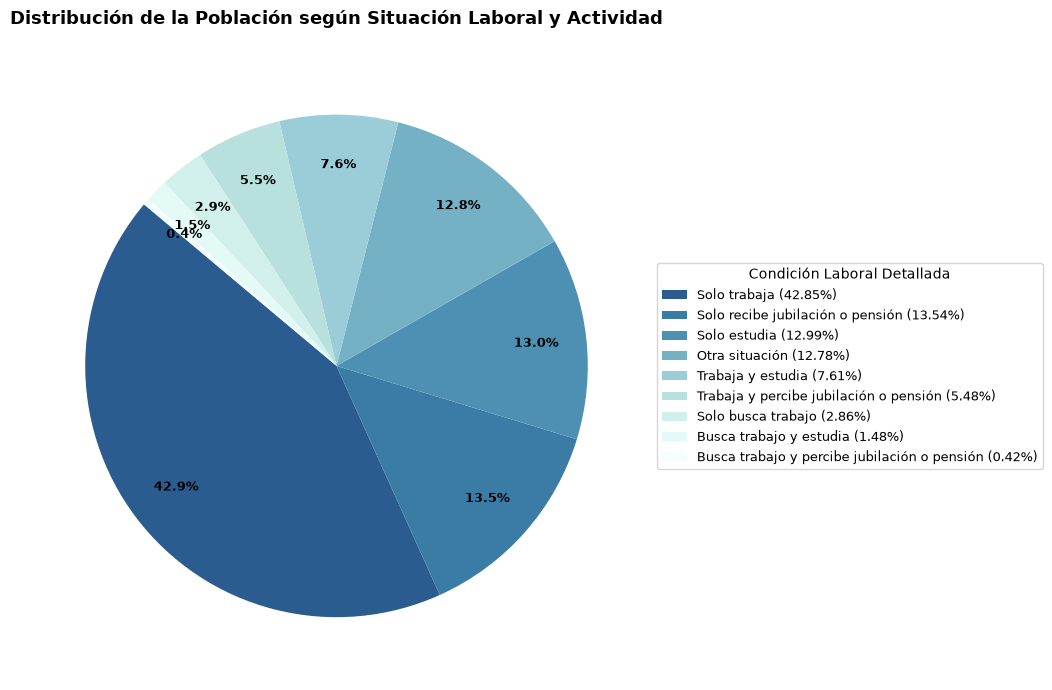

In [12]:
etiquetas = df_resultado["condicion_laboral_detallada"]
valores = df_resultado["total_personas"]
porcentajes = df_resultado["porcentaje"]

colores = [
    "#2b5c8f", "#3a7ca5", "#4d90b3", "#75b1c5", "#9bcdd8",
    "#b8e1dd", "#d1f0ec", "#e3faf7", "#f4fffd"
]

plt.figure(figsize=(11, 7), dpi=100)

wedges, texts, autotexts = plt.pie(
    valores, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colores,
    pctdistance=0.80,
    textprops=dict(color="black", weight="bold", size=9)
)

leyenda_etiquetas = [f"{lbl} ({pct}%)" for lbl, pct in zip(etiquetas, porcentajes)]

plt.legend(
    wedges, 
    leyenda_etiquetas,
    title="Condición Laboral Detallada",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), 
    fontsize=9,
    title_fontsize=10
)

plt.title("Distribución de la Población según Situación Laboral y Actividad", fontsize=13, weight="bold", pad=20)
plt.tight_layout()
plt.show()


In [17]:
from sqlalchemy import text


query_laboral_profundo = text("""
WITH universo_adulto AS (
    -- Seleccionamos la población activa o inactiva (Excluyendo jubilados y pensionados)
    SELECT 
        COALESCE(dg.departamento, 'Interior Disperso / Parajes') AS departamento,
        p.codigo AS id_radio,
        p.cantidad,
        CASE 
            WHEN dc.categoria IN ('Solo trabaja', 'Trabaja y estudia') THEN 'Ocupados'
            WHEN dc.categoria IN ('Solo busca trabajo', 'Busca trabajo y estudia') THEN 'Desocupados'
            WHEN dc.categoria IN ('Solo estudia', 'Otra situación') THEN 'Inactivos Puros'
            ELSE 'Otros'
        END AS situacion_empleo
    FROM fact_persona p
    JOIN dim_categorias dc ON p.id_categoria = dc.id_categoria
    LEFT JOIN dim_geografia dg ON TRIM(p.codigo) = TRIM(dg.codigo)
    WHERE dc.id_variable = 34 
      AND dc.categoria NOT LIKE '%jubilación%'
      AND dc.categoria NOT LIKE '%pensión%'
)
SELECT 
    departamento,
    SUM(CASE WHEN situacion_empleo = 'Ocupados' THEN cantidad ELSE 0 END) AS total_ocupados,
    SUM(CASE WHEN situacion_empleo = 'Desocupados' THEN cantidad ELSE 0 END) AS total_desocupados,
    SUM(CASE WHEN situacion_empleo = 'Inactivos Puros' THEN cantidad ELSE 0 END) AS total_inactivos_puros,
    -- Población Económicamente Activa (PEA)
    (SUM(CASE WHEN situacion_empleo = 'Ocupados' THEN cantidad ELSE 0 END) + 
     SUM(CASE WHEN situacion_empleo = 'Desocupados' THEN cantidad ELSE 0 END)) AS pea,
    -- Tasa de Desocupación Abierta (%) sobre la PEA
    ROUND((SUM(CASE WHEN situacion_empleo = 'Desocupados' THEN cantidad ELSE 0 END)::numeric / 
           NULLIF((SUM(CASE WHEN situacion_empleo = 'Ocupados' THEN cantidad ELSE 0 END) + 
                   SUM(CASE WHEN situacion_empleo = 'Desocupados' THEN cantidad ELSE 0 END)), 0)) * 100, 2) AS tasa_desocupacion,
    -- Tasa de Inactividad Pura (%) sobre el total de la población del mercado laboral evaluado
    ROUND((SUM(CASE WHEN situacion_empleo = 'Inactivos Puros' THEN cantidad ELSE 0 END)::numeric / 
           NULLIF(SUM(cantidad), 0)) * 100, 2) AS tasa_inactividad_pura
FROM universo_adulto
GROUP BY departamento
ORDER BY tasa_desocupacion DESC;
""")

df_laboral_profundo = pd.read_sql(query_laboral_profundo, engine)

print("Análisis del Mercado de Trabajo por Departamento (Salta 2022):")
display(df_laboral_profundo)


Análisis del Mercado de Trabajo por Departamento (Salta 2022):


,departamento,total_ocupados,total_desocupados,total_inactivos_puros,pea,tasa_desocupacion,tasa_inactividad_pura
0,General Guemes,19998.0,2392.0,11586.0,22390.0,10.68,34.10
1,Chicoana,8932.0,878.0,5419.0,9810.0,8.95,35.58
2,Metan,17783.0,1736.0,9174.0,19519.0,8.89,31.97
3,Rosario de Lerma,19340.0,1870.0,10348.0,21210.0,8.82,32.79
4,Capital,264236.0,24136.0,112316.0,288372.0,8.37,28.03
5,Los Andes,2567.0,229.0,1515.0,2796.0,8.19,35.14
6,Rosario de la Frontera,12181.0,997.0,6341.0,13178.0,7.57,32.49
7,Cerrillos,21744.0,1744.0,11121.0,23488.0,7.43,32.13
8,General Jose de San Martin,61807.0,4899.0,38743.0,66706.0,7.34,36.74
9,Santa Victoria,2548.0,194.0,2414.0,2742.0,7.08,46.82


In [18]:
query_inactivos_genero = text("""
WITH depto_genero AS (
    -- Calculamos la proporción real de hombres y mujeres por cada departamento
    SELECT 
        COALESCE(dg.departamento, 'Interior Disperso') AS departamento,
        SUM(CASE WHEN fp.id_categoria = 416 THEN fp.cantidad ELSE 0 END) AS total_mujeres,
        SUM(CASE WHEN fp.id_categoria = 417 THEN fp.cantidad ELSE 0 END) AS total_varones,
        SUM(fp.cantidad) AS poblacion_total_sexo
    FROM fact_persona fp
    LEFT JOIN dim_geografia dg ON TRIM(fp.codigo) = TRIM(dg.codigo)
    WHERE fp.id_categoria IN (416, 417)
    GROUP BY dg.departamento
),
depto_inactivos AS (
    -- Agrupamos los inactivos puros (estudian o situación no laboral) por departamento
    SELECT 
        COALESCE(dg.departamento, 'Interior Disperso') AS departamento,
        SUM(fp.cantidad) AS total_inactivos_puros
    FROM fact_persona fp
    JOIN dim_categorias dc ON fp.id_categoria = dc.id_categoria
    LEFT JOIN dim_geografia dg ON TRIM(fp.codigo) = TRIM(dg.codigo)
    WHERE dc.id_variable = 34 
      AND dc.categoria IN ('Solo estudia', 'Otra situación')
    GROUP BY dg.departamento
)
SELECT 
    i.departamento,
    i.total_inactivos_puros,
    -- Proyectamos los inactivos según la distribución demográfica de género del departamento
    ROUND(i.total_inactivos_puros * (g.total_mujeres::numeric / g.poblacion_total_sexo), 0) AS inactivos_mujeres,
    ROUND(i.total_inactivos_puros * (g.total_varones::numeric / g.poblacion_total_sexo), 0) AS inactivos_varones,
    ROUND((g.total_mujeres::numeric / g.poblacion_total_sexo) * 100, 2) AS porc_mujeres_depto
FROM depto_inactivos i
JOIN depto_genero g ON i.departamento = g.departamento
ORDER BY i.total_inactivos_puros DESC;
""")

df_inactivos_genero = pd.read_sql(query_inactivos_genero, engine)
print("Desglose de Inactivos Puros por Género y Departamento:")
display(df_inactivos_genero)

Desglose de Inactivos Puros por Género y Departamento:


,departamento,total_inactivos_puros,inactivos_mujeres,inactivos_varones,porc_mujeres_depto
0,Capital,112316.0,58782.0,53534.0,52.34
1,General Jose de San Martin,38743.0,19760.0,18983.0,51.00
2,Oran,33641.0,17017.0,16624.0,50.58
3,Anta,14578.0,7249.0,7329.0,49.72
4,General Guemes,11586.0,5909.0,5677.0,51.00
5,Cerrillos,11121.0,5679.0,5442.0,51.06
6,Rivadavia,10378.0,5150.0,5228.0,49.62
7,Rosario de Lerma,10348.0,5265.0,5083.0,50.88
8,Metan,9174.0,4659.0,4515.0,50.79
9,Rosario de la Frontera,6341.0,3241.0,3100.0,51.11


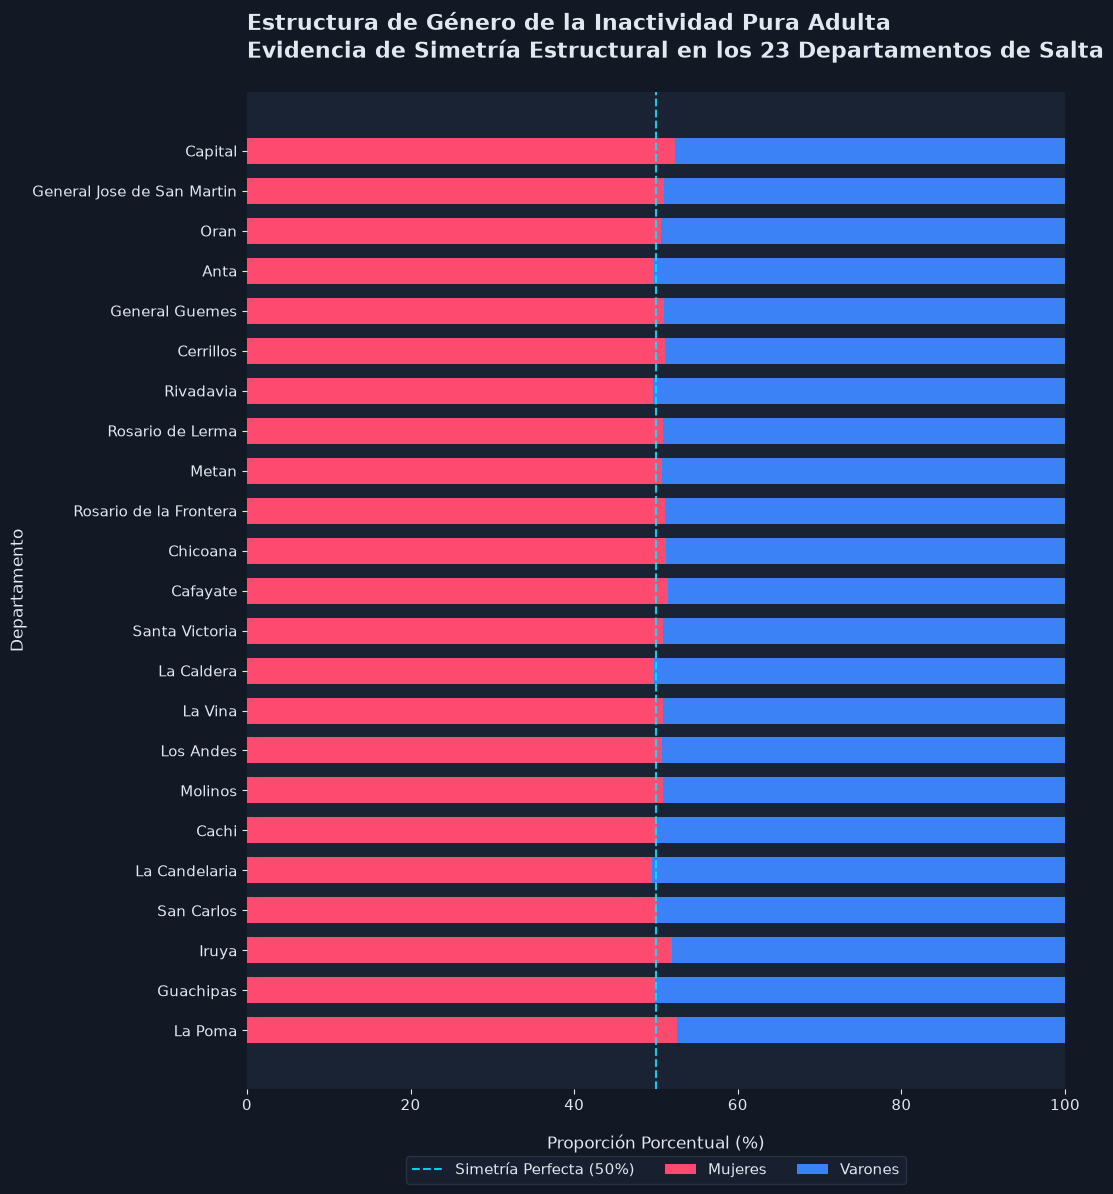

In [19]:
FONDO_OSCURO = '#121824'
FONDO_GRAFICO = '#1a2333'
COLOR_TEXTO = '#E2E8F0'
COLOR_GRILLA = '#2D3748'
COLOR_LINEA_50 = '#00E5FF'
COLOR_MUJERES = '#FF4A70'
COLOR_VARONES = '#3B82F6'

df_all_plot = df_inactivos_genero.copy()

df_all_plot['porc_mujeres'] = (df_all_plot['inactivos_mujeres'] / df_all_plot['total_inactivos_puros']) * 100
df_all_plot['porc_varones'] = (df_all_plot['inactivos_varones'] / df_all_plot['total_inactivos_puros']) * 100

df_all_plot = df_all_plot.sort_values(by='total_inactivos_puros', ascending=True)

fig, ax = plt.subplots(figsize=(11, 12), facecolor=FONDO_OSCURO)
ax.set_facecolor(FONDO_GRAFICO)

bars_m = ax.barh(df_all_plot['departamento'], df_all_plot['porc_mujeres'], color=COLOR_MUJERES, label='Mujeres', height=0.65)
bars_v = ax.barh(df_all_plot['departamento'], df_all_plot['porc_varones'], left=df_all_plot['porc_mujeres'], color=COLOR_VARONES, label='Varones', height=0.65)

ax.axvline(x=50, color=COLOR_LINEA_50, linestyle='--', linewidth=1.5, alpha=0.9, label='Simetría Perfecta (50%)')

ax.set_title("Estructura de Género de la Inactividad Pura Adulta\nEvidencia de Simetría Estructural en los 23 Departamentos de Salta", 
             fontsize=16, fontweight='bold', pad=25, loc='left', color=COLOR_TEXTO)
ax.set_xlabel("Proporción Porcentual (%)", fontsize=12, labelpad=15, color=COLOR_TEXTO)
ax.set_ylabel("Departamento", fontsize=12, color=COLOR_TEXTO)
ax.set_xlim(0, 100)

ax.tick_params(axis='x', colors=COLOR_TEXTO, labelsize=11)
ax.tick_params(axis='y', colors=COLOR_TEXTO, labelsize=11)
ax.grid(False)
sns.despine(left=True, bottom=True)

leyenda = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=3, frameon=True, fontsize=11)
leyenda.get_frame().set_facecolor(FONDO_GRAFICO)
leyenda.get_frame().set_edgecolor(COLOR_GRILLA)
for text in leyenda.get_texts():
    text.set_color(COLOR_TEXTO)

plt.tight_layout()
plt.show()

In [20]:
query_critica = """
WITH metrics_nbi AS (
    SELECT 
        fh.codigo AS id_radio,
        SUM(CASE WHEN LOWER(TRIM(dc.categoria)) = 'sí' THEN fh.cantidad ELSE 0 END) AS hogares_nbi,
        SUM(fh.cantidad) AS total_hogares_nbi
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    WHERE dv.cod_variable = 'HOGAR_NBI_TOT'
    GROUP BY fh.codigo
),
metrics_escritura AS (
    SELECT 
        fh.codigo AS id_radio,
        SUM(fh.cantidad) - SUM(CASE WHEN dc.cod_categoria = 1 THEN fh.cantidad ELSE 0 END) AS hogares_sin_escritura,
        SUM(fh.cantidad) AS total_hogares_escritura
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    WHERE dv.cod_variable = 'HOGAR_H23'
    GROUP BY fh.codigo
),
metrics_internet AS (
    SELECT 
        fh.codigo AS id_radio,
        SUM(fh.cantidad) - SUM(CASE WHEN dc.cod_categoria = 1 THEN fh.cantidad ELSE 0 END) AS hogares_sin_internet,
        SUM(fh.cantidad) AS total_hogares_internet
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    WHERE dv.cod_variable = 'HOGAR_H24A'
    GROUP BY fh.codigo
)
SELECT 
    COALESCE(dg.departamento, 'Desconocido/Interior') AS departamento,
    gr.id_radio,
    n.total_hogares_nbi AS total_hogares,
    n.hogares_nbi,
    ROUND((n.hogares_nbi::numeric / n.total_hogares_nbi) * 100, 2) AS porc_nbi,
    e.hogares_sin_escritura,
    ROUND((e.hogares_sin_escritura::numeric / e.total_hogares_escritura) * 100, 2) AS porc_informalidad,
    i.hogares_sin_internet,
    ROUND((i.hogares_sin_internet::numeric / i.total_hogares_internet) * 100, 2) AS porc_sin_internet,
    -- Índice compuesto simple (Promedio de las tres privaciones)
    ROUND((
        ((n.hogares_nbi::numeric / n.total_hogares_nbi) * 100) + 
        ((e.hogares_sin_escritura::numeric / e.total_hogares_escritura) * 100) + 
        ((i.hogares_sin_internet::numeric / i.total_hogares_internet) * 100)
    ) / 3, 2) AS indice_vulnerabilidad_critica,
    gr.geometry
FROM (
    SELECT codigo AS id_radio, departamento, geometry FROM public.geo_radios_2022
) gr
JOIN metrics_nbi n ON TRIM(gr.id_radio) = TRIM(n.id_radio)
JOIN metrics_escritura e ON TRIM(gr.id_radio) = TRIM(e.id_radio)
JOIN metrics_internet i ON TRIM(gr.id_radio) = TRIM(i.id_radio)
LEFT JOIN dim_geografia dg ON TRIM(gr.id_radio) = TRIM(dg.codigo)
WHERE n.total_hogares_nbi >= 30 -- Filtro de relevancia estadística para evitar sesgos
ORDER BY indice_vulnerabilidad_critica DESC;
"""

geo_df_critico = gpd.read_postgis(query_critica, engine, geom_col="geometry", crs="EPSG:4326")

print("Top 50 Radios Censales con Emergencia Estructural Sistémica:")
display(geo_df_critico[["departamento", "id_radio", "total_hogares", "porc_nbi", "porc_informalidad", "porc_sin_internet", "indice_vulnerabilidad_critica"]].head(50))

Top 50 Radios Censales con Emergencia Estructural Sistémica:


,departamento,id_radio,total_hogares,porc_nbi,porc_informalidad,porc_sin_internet,indice_vulnerabilidad_critica
0,General Jose de San Martin,660560706,184.0,77.17,100.00,98.37,91.85
1,General Jose de San Martin,660560308,205.0,58.05,93.05,99.02,83.37
2,Rivadavia,661330210,351.0,62.96,97.87,89.17,83.34
3,General Jose de San Martin,660560311,207.0,56.04,89.39,100.00,81.81
4,Rivadavia,661330108,251.0,62.95,90.83,91.24,81.67
5,General Jose de San Martin,660560707,290.0,51.38,98.91,93.45,81.24
6,Rivadavia,661330109,166.0,60.24,89.17,91.57,80.33
7,Oran,661261407,235.0,41.70,98.62,95.74,78.69
8,General Jose de San Martin,660560310,279.0,40.14,93.42,99.28,77.61
9,Rivadavia,661330411,126.0,49.21,82.24,100.00,77.15
